#### Users and Friendships

In [61]:
users = [
    {'id':0, 'name':'Hero'},
    {'id':1, 'name':'Dunn'},
    {'id':2, 'name':'Sue'},
    {'id':3, 'name':'Chi'},
    {'id':4, 'name':'Thor'},
    {'id':5, 'name':'Clive'},
    {'id':6, 'name':'Hicks'},
    {'id':7, 'name':'Devin'},
    {'id':8, 'name':'Kate'},
    {'id':9, 'name':'Klein'},
    {'id':10, 'name':'Jen'}]

# 24 for friend connections listed
friendships = [(0,1), (0,2), (1,2), (1,3), (2,3), (3,4),
               (4,5), (5,6), (5,7), (6,8), (7,8), (8,9)]

# Add friends to each user in the list dictionary
for user in users:
    user["friends"]=[]

# With each friendship pair add it to the key...
for i, j in friendships:
    users[i]['friends'].append(users[j]) # add j as a friend of i
    users[j]['friends'].append(users[i]) # add i as a friend of j

In [62]:
# Create function to determine how many friends a person has
def number_of_friends(user):
    return len(user["friends"])

total_connections= sum(number_of_friends(user) for user in users)
print(f'Total number of connections: {total_connections}')
print(f'Number of users: {len(users)}')
print(f'Average number of friends per user: {round(total_connections/len(users),2)}')

Total number of connections: 24
Number of users: 11
Average number of friends per user: 2.18


In [63]:
# Create list of users ids and there number of friends
num_friends_by_id = [(user["id"], number_of_friends(user))
                     for user in users]

In [64]:
# Sort the users by the number of friends they have
sorted(num_friends_by_id,
       key=lambda num_friends: num_friends[1],
       reverse=True)

[(1, 3),
 (2, 3),
 (3, 3),
 (5, 3),
 (8, 3),
 (0, 2),
 (4, 2),
 (6, 2),
 (7, 2),
 (9, 1),
 (10, 0)]

#### Data Scientists You May Know

In [65]:
def friends_of_friend_ids_bad(user):
    return [foaf['id']
            for friend in user['friends']
            for foaf in friend['friends']]

In [66]:
# Find the friends of friends of Hero
friends_of_friend_ids_bad(users[0])

[0, 2, 3, 0, 1, 3]

In [67]:
from collections import Counter

In [68]:
def not_the_same(user, other_user):
    return user['id'] != other_user['id']

def not_friends(user, other_user):
    return all(not_the_same(friend, other_user)
               for friend in user['friends'])

def friends_of_friends_ids(user):
    return Counter(foaf['id']
                   for friend in user['friends']
                   for foaf in friend['friends']
                   if not_the_same(user, foaf)
                   and not_friends(user, foaf))

In [69]:
# Show the mutual friends of user Chi
print(friends_of_friends_ids(users[3]))

Counter({0: 2, 5: 1})


In [70]:
# Build list of interests for users
interests = [
    (0, "Hadoop"), (0, "Big Data"), (0, "HBase"), (0, "Java"),
    (0, "Spark"), (0, "Storm"), (0, "Cassandra"),
    (1, "NoSQL"), (1, "MongoDB"), (1, "Cassandra"), (1, "HBase"),
    (1, "Postgres"), (2, "Python"), (2, "scikit-learn"), (2, "scipy"),
    (2, "numpy"), (2, "statsmodels"), (2, "pandas"), (3, "R"), (3, "Python"),
    (3, "statistics"), (3, "regression"), (3, "probability"),
    (4, "machine learning"), (4, "regression"), (4, "decision trees"),
    (4, "libsvm"), (5, "Python"), (5, "R"), (5, "Java"), (5, "C++"),
    (5, "Haskell"), (5, "programming languages"), (6, "statistics"),
    (6, "probability"), (6, "mathematics"), (6, "theory"),
    (7, "machine learning"), (7, "scikit-learn"), (7, "Mahout"),
    (7, "neural networks"), (8, "neural networks"), (8, "deep learning"),
    (8, "Big Data"), (8, "artificial intelligence"), (9, "Hadoop"),
    (9, "Java"), (9, "MapReduce"), (9, "Big Data")
]

In [71]:
def data_scientists_who_like(target_interest):
    return [user_id
            for user_id, user_interest in interests
            if user_interest == target_interest]

In [72]:
from collections import defaultdict

# keys are interests, values are lists of user_ids with that interest
user_ids_by_interest = defaultdict(list)

for user_id, interest in interests:
    user_ids_by_interest[interest].append(user_id)

# keys are user_ids, values are lists of interests for that user_id
interests_by_user_id = defaultdict(list)

for user_id, interest in interests:
    interests_by_user_id[user_id].append(interest)

In [73]:
# Show users with the interest in Hadoop
user_ids_by_interest['Hadoop']

[0, 9]

In [74]:
# Display interests for user_id Chi
interests_by_user_id[3]

['R', 'Python', 'statistics', 'regression', 'probability']

In [75]:
def most_common_interests_with(user_id):
    return Counter(interested_user_id
        for interest in interests_by_user_id["user_id"]
        for interested_user_id in user_ids_by_interest[interest]
        if interested_user_id != user_id)

#### Salaries and Experience

In [76]:
salaries_and_tenures = [(83000, 8.7), (88000, 8.1),
                        (48000, 0.7), (76000, 6),
                        (69000, 6.5), (76000, 7.5),
                        (60000, 2.5), (83000, 10),
                        (48000, 1.9), (63000, 4.2)]

In [99]:
import matplotlib.pyplot as plt

def make_chart_salaries_by_tenure():
    tenures = [tenure for salary, tenure in salaries_and_tenures]
    salaries = [salary for salary, tenure in salaries_and_tenures]
    plt.figure(figsize=(3,3))
    plt.scatter(tenures, salaries)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlabel('Years Experience')
    plt.ylabel('Salary')
    plt.grid(True)
    plt.show()

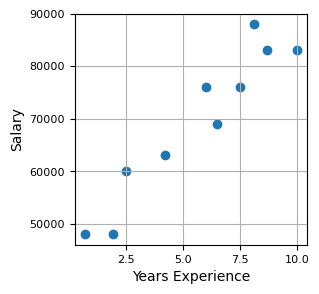

In [100]:
make_chart_salaries_by_tenure()

#### Average Salary By Tenure

In [80]:
salary_by_tenure = defaultdict(list)

In [103]:
for salary, tenure in salaries_and_tenures:
    salary_by_tenure[tenure].append(salary)

# Create a dictionary of the average salary (item) by tenure (key)
average_salary_by_tenure = {
    tenure : sum(salaries) / len(salaries)
    for tenure, salaries in salary_by_tenure.items()}

In [104]:
average_salary_by_tenure

{8.7: 83000.0,
 8.1: 88000.0,
 0.7: 48000.0,
 6: 76000.0,
 6.5: 69000.0,
 7.5: 76000.0,
 2.5: 60000.0,
 10: 83000.0,
 1.9: 48000.0,
 4.2: 63000.0}

In [107]:
def tenure_bucket(tenure):
    if tenure < 2: return "less than two"
    elif tenure < 5: return "between two and five"
    else: return "more than five"

salary_by_tenure_bucket = defaultdict(list)

for salary, tenure in salaries_and_tenures:
    bucket = tenure_bucket(tenure)
    salary_by_tenure_bucket[bucket].append(salary)

average_salary_by_bucket = {
    tenure_bucket : sum(salaries) / len(salaries)
    for tenure_bucket, salaries in salary_by_tenure_bucket.items()}

In [109]:
# Display average salary by tenure bucket
average_salary_by_bucket

{'more than five': 79166.66666666667,
 'less than two': 48000.0,
 'between two and five': 61500.0}

#### Paid Accounts

In [110]:
def predict_paid_or_unpaid(years_experience):
    if years_experience < 3.0: return "paid"
    elif years_experience < 8.5: return "unpaid"
    else: return "paid"